In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

def compute_t_stat(values, errors):
    t = +values
    mask = errors != 0
    t[mask] /= errors[mask]
    return t

In [3]:
t_19 = 3.579 # threshold of one-tailed t statistics for 19 dof and p=0.001

### Identical Rosslers

In [19]:
taus_eq = np.logspace(-1,1,21)


In [4]:
taus_eq = np.logspace(-1,1,21)
Ls = np.linspace(100,30000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles_identical/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles_identical/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(taus_eq)))
egc_index_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles_identical/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(taus_eq),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(taus_eq),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles_identical/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(taus_eq)))
L_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles_identical/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(taus_eq)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(taus_eq))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"./transfer_entropy/pickles_identical/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])


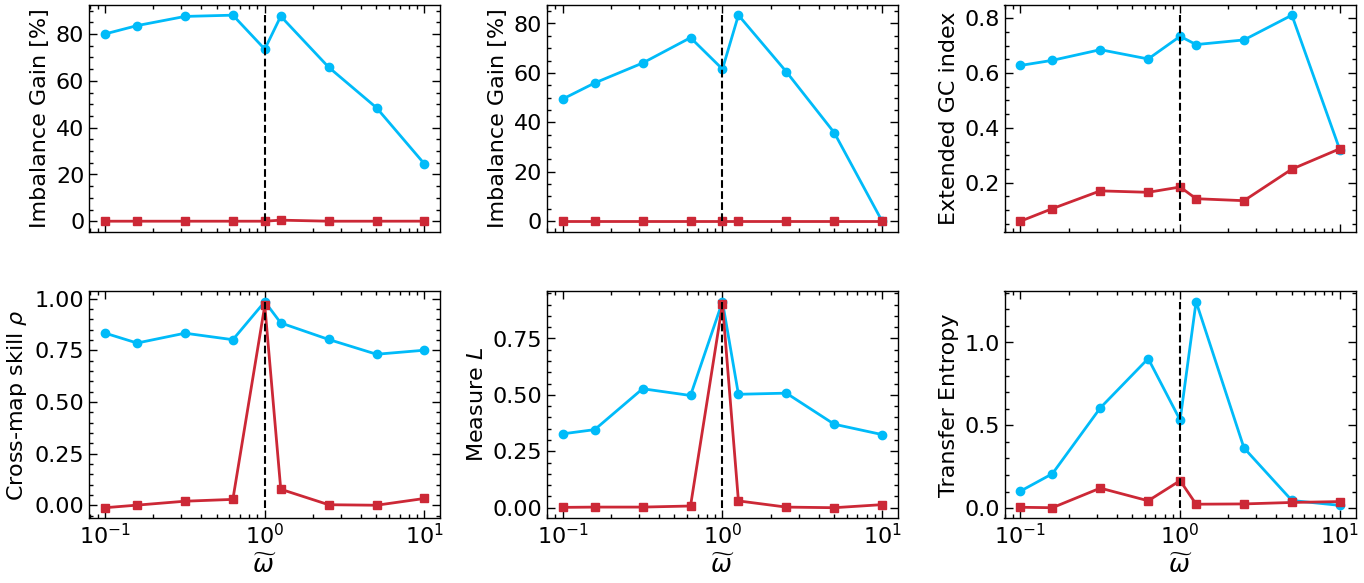

In [6]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()
min = 0.3
max = 3.1

indices = np.sort(np.append(np.arange(0,21,3), [10,20]))

#ax[0,0].errorbar(1/taus_eq[indices], IGs_X_to_Y[indices], IGs_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,0].errorbar(1/taus_eq[indices], IGs_Y_to_X[indices], IGs_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(1/taus_eq[indices], IGs_X_to_Y[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,0].plot(1/taus_eq[indices], IGs_Y_to_X[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,0].vlines(1., np.min(IGs_Y_to_X[indices]), np.max(IGs_X_to_Y[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,0].set(ylabel="Imbalance Gain [%]", xscale="log")#, xlim=[min,max])
ax[0,0].axes.xaxis.set_ticklabels([])

#ax[0,1].errorbar(1/taus_eq[indices], IGs_X_to_Y_emb[indices], IGs_X_to_Y_err_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,1].errorbar(1/taus_eq[indices], IGs_Y_to_X_emb[indices], IGs_Y_to_X_err_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(1/taus_eq[indices], IGs_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,1].plot(1/taus_eq[indices], IGs_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,1].vlines(1., np.min(IGs_Y_to_X_emb[indices]), np.max(IGs_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,1].set(ylabel="Imbalance Gain [%]", xscale="log")#,, xlim=[min,max])
ax[0,1].axes.xaxis.set_ticklabels([])

#ax[0,2].errorbar(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], egc_index_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,2].errorbar(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], egc_index_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,2].plot(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,2].vlines(1., np.min(egc_index_Y_to_X_avg[indices]), np.max(egc_index_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,2].set(ylabel="Extended GC index", xscale="log")#,, xlim=[min,max])
ax[0,2].axes.xaxis.set_ticklabels([])

#ax[1,0].errorbar(1/taus_eq[indices], ccm_X_to_Y_avg[indices], ccm_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,0].errorbar(1/taus_eq[indices], ccm_Y_to_X_avg[indices], ccm_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(1/taus_eq[indices], ccm_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,0].plot(1/taus_eq[indices], ccm_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,0].vlines(1., np.min(ccm_Y_to_X_avg[indices]), np.max(ccm_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,0].set(ylabel="Cross-map skill $\\rho$", xscale="log")#,, xlim=[min,max])
ax[1,0].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,1].errorbar(1/taus_eq[indices], L_X_to_Y_avg[indices], L_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,1].errorbar(1/taus_eq[indices], L_Y_to_X_avg[indices], L_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(1/taus_eq[indices], L_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)#
ax[1,1].plot(1/taus_eq[indices], L_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)#
ax[1,1].vlines(1., np.min(L_Y_to_X_avg[indices]), np.max(L_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,1].set(ylabel="Measure $L$", xscale="log")#,, xlim=[min,max])
ax[1,1].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], TE_err_X_to_Y_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], TE_err_Y_to_X_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].plot(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,2].plot(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,2].vlines(1., np.min(TE_mean_Y_to_X_emb[indices]), np.max(TE_mean_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,2].set(ylabel="Transfer Entropy", xscale="log")#,, xlim=[min,max])
ax[1,2].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#plt.savefig("./figures/measures_vs_omega.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Plot attractors of X for different tau_eq

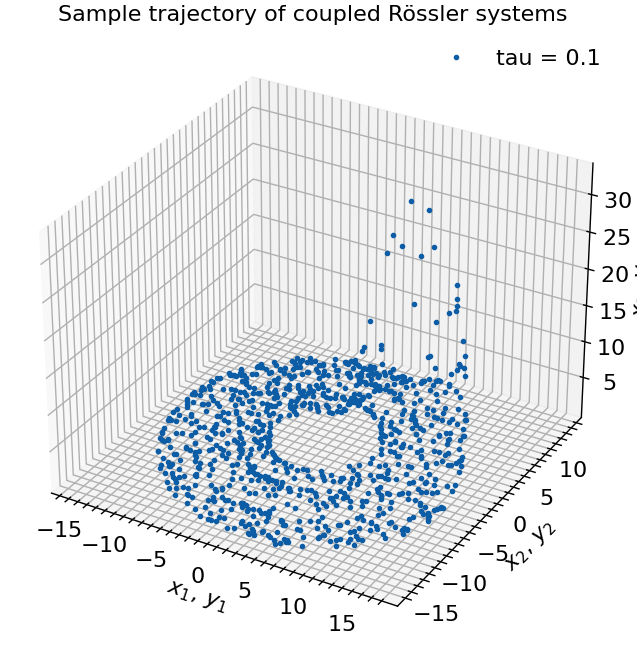

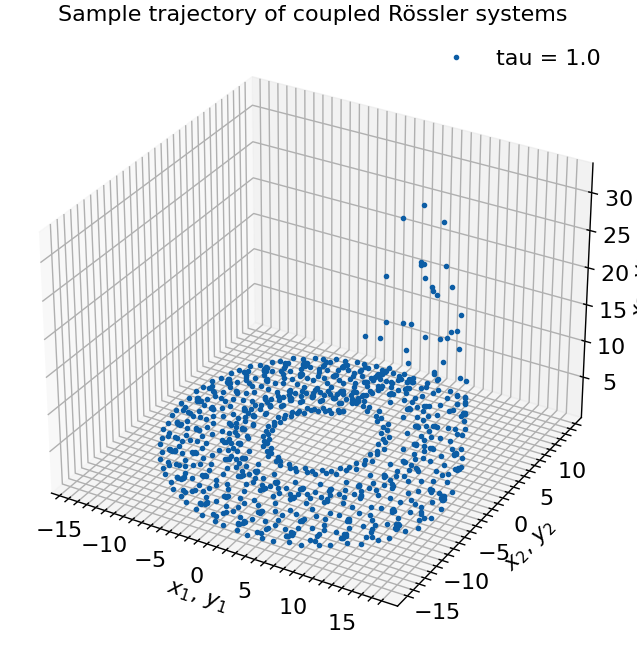

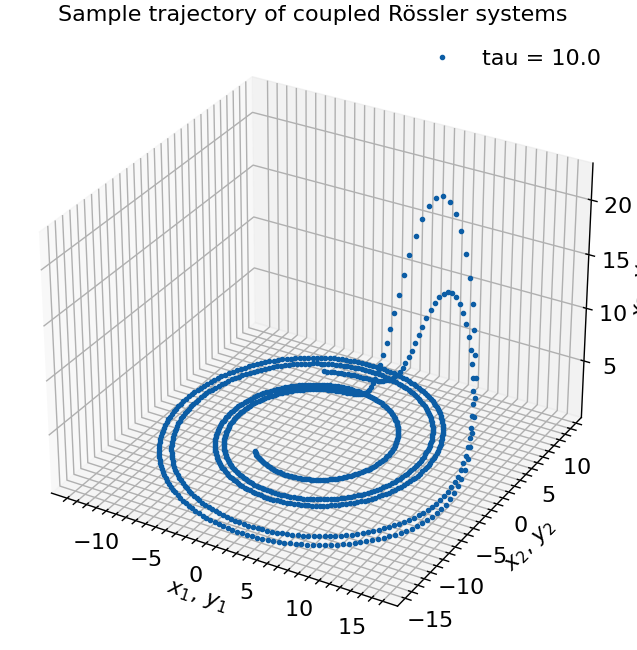

In [7]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs_identical/seed0_itau{itau_eq}.p","rb"))

    start_plot = 198000
    end_plot = 198900 #+ int(500 * taus_eq[itau_eq])

    x_1 = trajectory[start_plot:end_plot,1]
    x_2 = trajectory[start_plot:end_plot,2]
    x_3 = trajectory[start_plot:end_plot,3]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(x_1, x_2, x_3, '.', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$x_1,\,y_1$")
    ax.set_ylabel("$x_2,\,y_2$")
    ax.set_zlabel("$x_3,\,y_3$")
    plt.legend()
    plt.show()

### Plot attractors of Y for different tau_eq

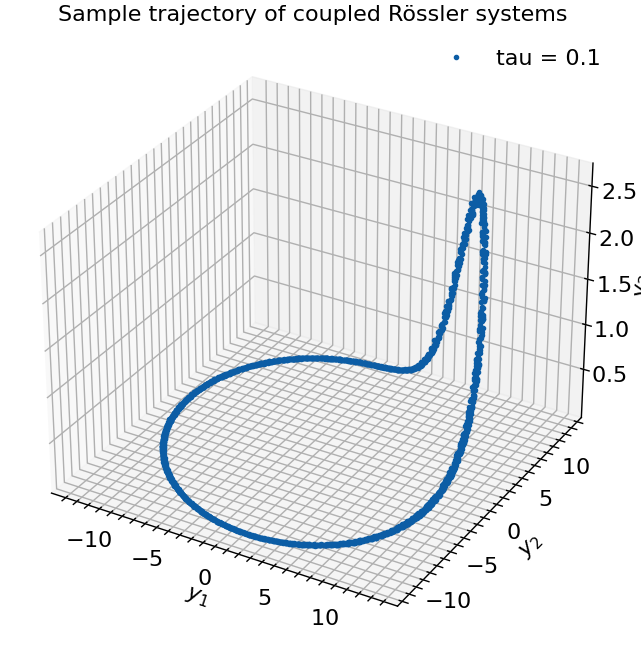

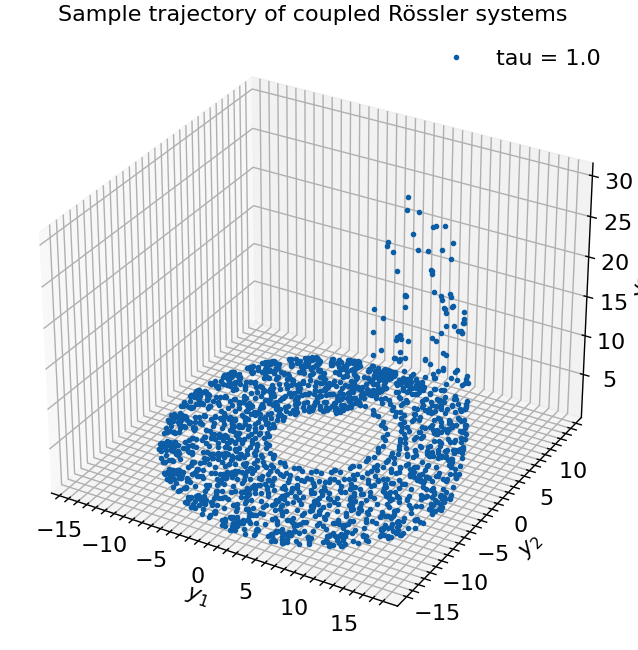

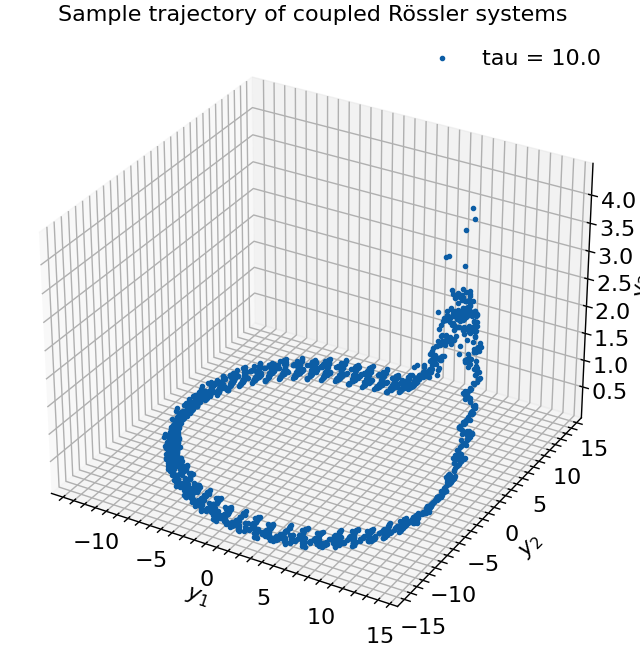

In [8]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs_identical/seed0_itau{itau_eq}.p","rb"))

    start_plot = 198000
    end_plot = 199900 #+ int(500 * taus_eq[itau_eq])

    y_1 = trajectory[start_plot:end_plot,4]
    y_2 = trajectory[start_plot:end_plot,5]
    y_3 = trajectory[start_plot:end_plot,6]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(y_1, y_2, y_3, '.', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$y_1$")
    ax.set_ylabel("$y_2$")
    ax.set_zlabel("$y_3$")
    plt.legend()
    plt.show()

### Different Rosslers

In [19]:
taus_eq = np.logspace(-1,1,21)
Ls = np.linspace(100,20000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(taus_eq)))
egc_index_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(taus_eq),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(taus_eq),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(taus_eq)))
L_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L_allcoords/pickles/seed{seed}.p","rb")) #ALLCOORDS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(taus_eq)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(taus_eq))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"./transfer_entropy/pickles/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])


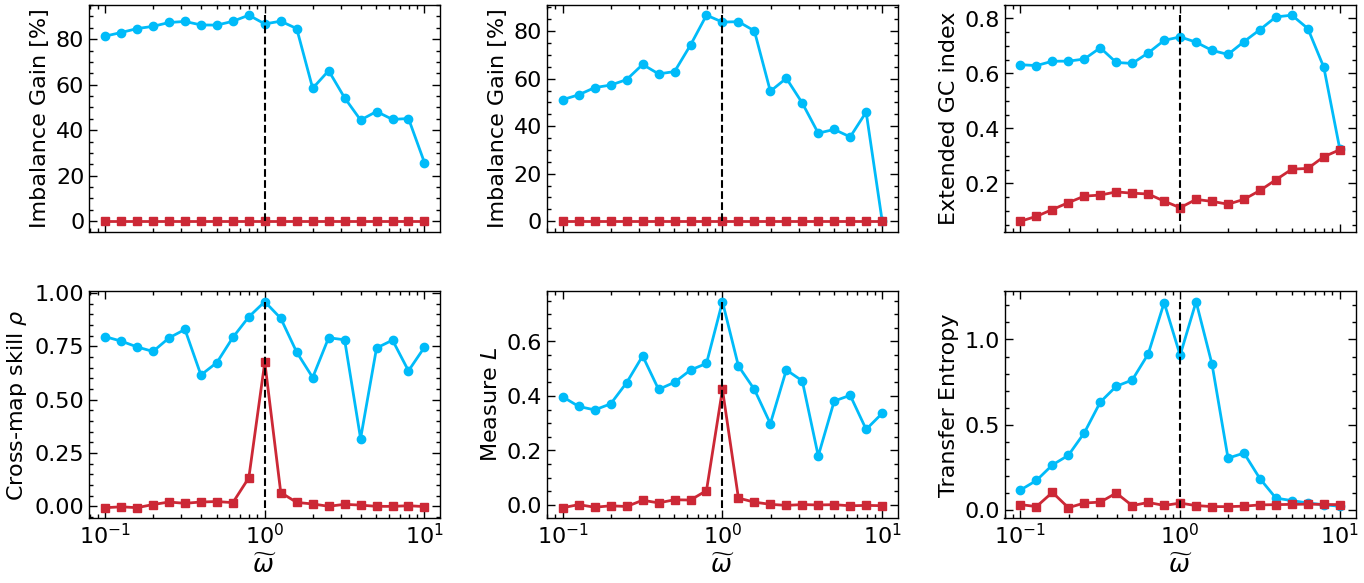

In [11]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()
min = 0.3
max = 3.1

indices = np.arange(0,21)#np.sort(np.append(np.arange(0,21,3), [10,20]))

#ax[0,0].errorbar(1/taus_eq[indices], IGs_X_to_Y[indices], IGs_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,0].errorbar(1/taus_eq[indices], IGs_Y_to_X[indices], IGs_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(1/taus_eq[indices], IGs_X_to_Y[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,0].plot(1/taus_eq[indices], IGs_Y_to_X[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,0].vlines(1., np.min(IGs_Y_to_X[indices]), np.max(IGs_X_to_Y[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,0].set(ylabel="Imbalance Gain [%]", xscale="log")#, xlim=[min,max])
ax[0,0].axes.xaxis.set_ticklabels([])

#ax[0,1].errorbar(1/taus_eq[indices], IGs_X_to_Y_emb[indices], IGs_X_to_Y_err_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,1].errorbar(1/taus_eq[indices], IGs_Y_to_X_emb[indices], IGs_Y_to_X_err_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(1/taus_eq[indices], IGs_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,1].plot(1/taus_eq[indices], IGs_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,1].vlines(1., np.min(IGs_Y_to_X_emb[indices]), np.max(IGs_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,1].set(ylabel="Imbalance Gain [%]", xscale="log")#,, xlim=[min,max])
ax[0,1].axes.xaxis.set_ticklabels([])

#ax[0,2].errorbar(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], egc_index_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,2].errorbar(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], egc_index_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,2].plot(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,2].vlines(1., np.min(egc_index_Y_to_X_avg[indices]), np.max(egc_index_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,2].set(ylabel="Extended GC index", xscale="log")#,, xlim=[min,max])
ax[0,2].axes.xaxis.set_ticklabels([])

#ax[1,0].errorbar(1/taus_eq[indices], ccm_X_to_Y_avg[indices], ccm_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,0].errorbar(1/taus_eq[indices], ccm_Y_to_X_avg[indices], ccm_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(1/taus_eq[indices], ccm_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,0].plot(1/taus_eq[indices], ccm_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,0].vlines(1., np.min(ccm_Y_to_X_avg[indices]), np.max(ccm_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,0].set(ylabel="Cross-map skill $\\rho$", xscale="log")#,, xlim=[min,max])
ax[1,0].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,1].errorbar(1/taus_eq[indices], L_X_to_Y_avg[indices], L_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,1].errorbar(1/taus_eq[indices], L_Y_to_X_avg[indices], L_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(1/taus_eq[indices], L_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)#
ax[1,1].plot(1/taus_eq[indices], L_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)#
ax[1,1].vlines(1., np.min(L_Y_to_X_avg[indices]), np.max(L_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,1].set(ylabel="Measure $L$", xscale="log")#,, xlim=[min,max])
ax[1,1].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], TE_err_X_to_Y_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], TE_err_Y_to_X_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].plot(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,2].plot(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,2].vlines(1., np.min(TE_mean_Y_to_X_emb[indices]), np.max(TE_mean_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,2].set(ylabel="Transfer Entropy", xscale="log")#,, xlim=[min,max])
ax[1,2].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#plt.savefig("./figures/measures_vs_omega.pdf", dpi=300, bbox_inches='tight')
plt.show()

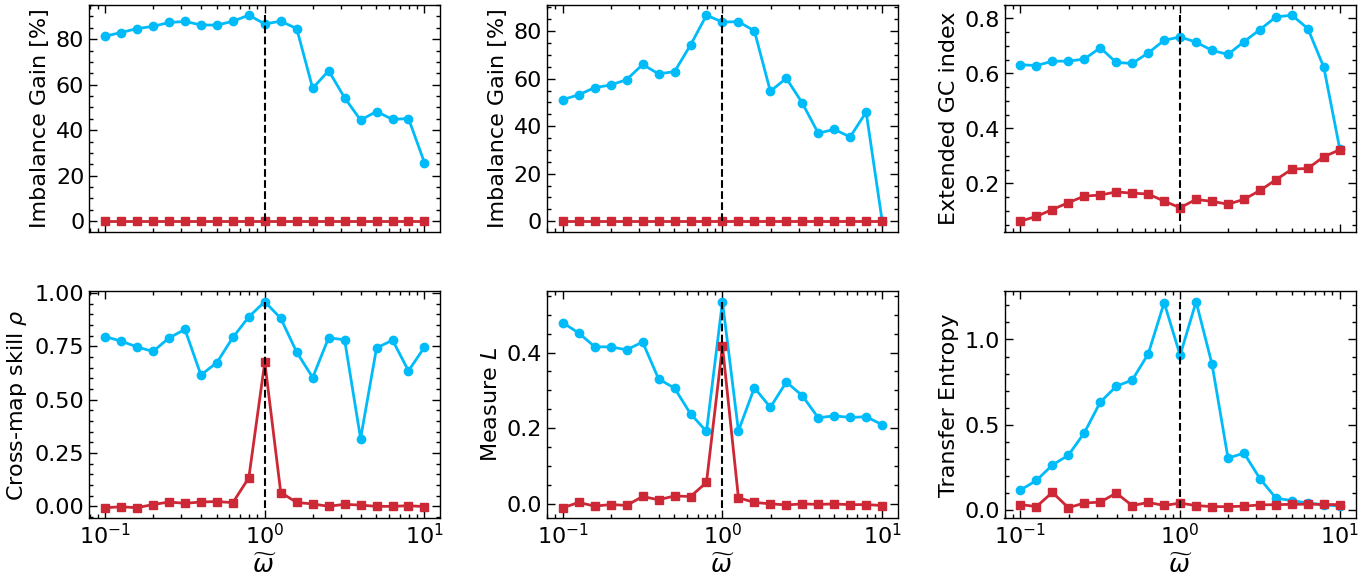

In [20]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()
min = 0.3
max = 3.1

indices = np.arange(0,21)#np.sort(np.append(np.arange(0,21,3), [10,20]))

#ax[0,0].errorbar(1/taus_eq[indices], IGs_X_to_Y[indices], IGs_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,0].errorbar(1/taus_eq[indices], IGs_Y_to_X[indices], IGs_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(1/taus_eq[indices], IGs_X_to_Y[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,0].plot(1/taus_eq[indices], IGs_Y_to_X[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,0].vlines(1., np.min(IGs_Y_to_X[indices]), np.max(IGs_X_to_Y[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,0].set(ylabel="Imbalance Gain [%]", xscale="log")#, xlim=[min,max])
ax[0,0].axes.xaxis.set_ticklabels([])

#ax[0,1].errorbar(1/taus_eq[indices], IGs_X_to_Y_emb[indices], IGs_X_to_Y_err_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,1].errorbar(1/taus_eq[indices], IGs_Y_to_X_emb[indices], IGs_Y_to_X_err_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(1/taus_eq[indices], IGs_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,1].plot(1/taus_eq[indices], IGs_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,1].vlines(1., np.min(IGs_Y_to_X_emb[indices]), np.max(IGs_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,1].set(ylabel="Imbalance Gain [%]", xscale="log")#,, xlim=[min,max])
ax[0,1].axes.xaxis.set_ticklabels([])

#ax[0,2].errorbar(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], egc_index_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,2].errorbar(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], egc_index_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,2].plot(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,2].vlines(1., np.min(egc_index_Y_to_X_avg[indices]), np.max(egc_index_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,2].set(ylabel="Extended GC index", xscale="log")#,, xlim=[min,max])
ax[0,2].axes.xaxis.set_ticklabels([])

#ax[1,0].errorbar(1/taus_eq[indices], ccm_X_to_Y_avg[indices], ccm_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,0].errorbar(1/taus_eq[indices], ccm_Y_to_X_avg[indices], ccm_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(1/taus_eq[indices], ccm_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,0].plot(1/taus_eq[indices], ccm_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,0].vlines(1., np.min(ccm_Y_to_X_avg[indices]), np.max(ccm_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,0].set(ylabel="Cross-map skill $\\rho$", xscale="log")#,, xlim=[min,max])
ax[1,0].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,1].errorbar(1/taus_eq[indices], L_X_to_Y_avg[indices], L_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,1].errorbar(1/taus_eq[indices], L_Y_to_X_avg[indices], L_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(1/taus_eq[indices], L_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)#
ax[1,1].plot(1/taus_eq[indices], L_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)#
ax[1,1].vlines(1., np.min(L_Y_to_X_avg[indices]), np.max(L_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,1].set(ylabel="Measure $L$", xscale="log")#,, xlim=[min,max])
ax[1,1].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], TE_err_X_to_Y_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], TE_err_Y_to_X_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].plot(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,2].plot(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,2].vlines(1., np.min(TE_mean_Y_to_X_emb[indices]), np.max(TE_mean_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,2].set(ylabel="Transfer Entropy", xscale="log")#,, xlim=[min,max])
ax[1,2].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#plt.savefig("./figures/measures_vs_omega.pdf", dpi=300, bbox_inches='tight')
plt.show()

(20, 21) (20, 21)


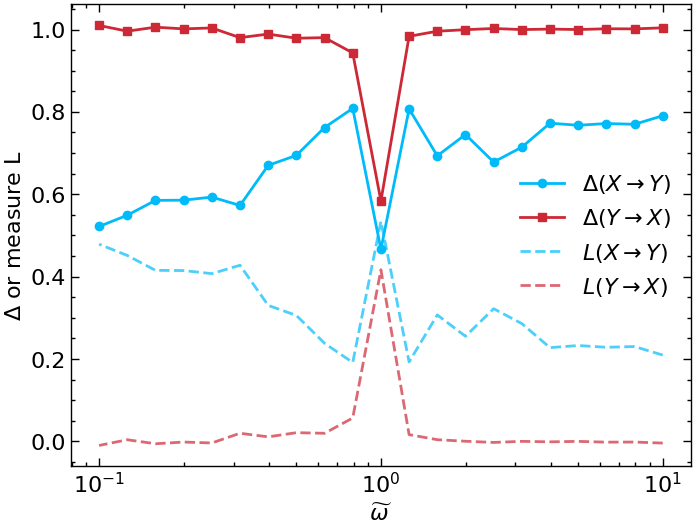

In [24]:
# from L measure to info imbalance
N = 5000
k = 5

imbs_X_to_Y = 1.0 - (N-k-1) / N * L_X_to_Y
imbs_Y_to_X = 1.0 - (N-k-1) / N * L_Y_to_X
print(imbs_X_to_Y.shape, imbs_Y_to_X.shape)

plt.plot(1/taus_eq, imbs_X_to_Y.mean(axis=0), 'o-', color=colors[0], label="$\\Delta(X\\rightarrow Y)$")
plt.plot(1/taus_eq, imbs_Y_to_X.mean(axis=0), 's-', color=colors[1], label="$\\Delta(Y\\rightarrow X)$")
plt.plot(1/taus_eq, L_X_to_Y.mean(axis=0), '--', color=colors[0], label="$L(X\\rightarrow Y)$", alpha=0.7)
plt.plot(1/taus_eq, L_Y_to_X.mean(axis=0), '--', color=colors[1], label="$L(Y\\rightarrow X)$", alpha=0.7)
plt.xlabel("$\\widetilde{\\omega}$")
plt.ylabel("$\\Delta$ or measure L")
plt.legend()
plt.xscale("log")
plt.show()

### Plot attractors of X for different tau_eq

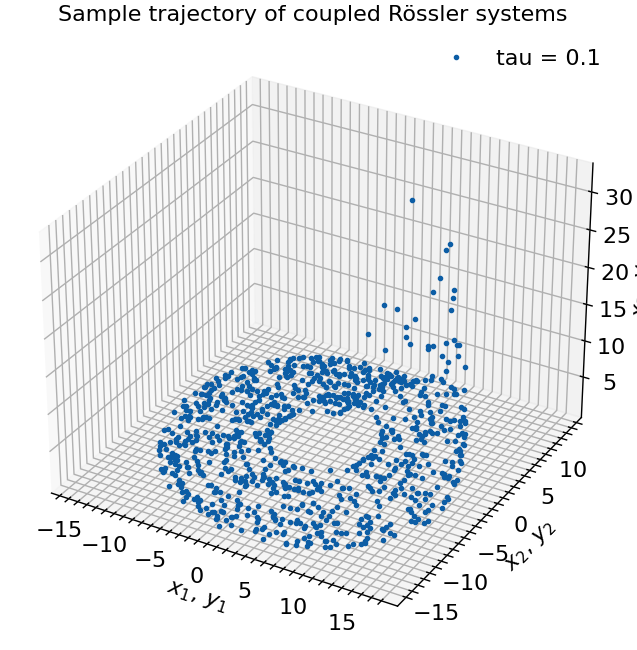

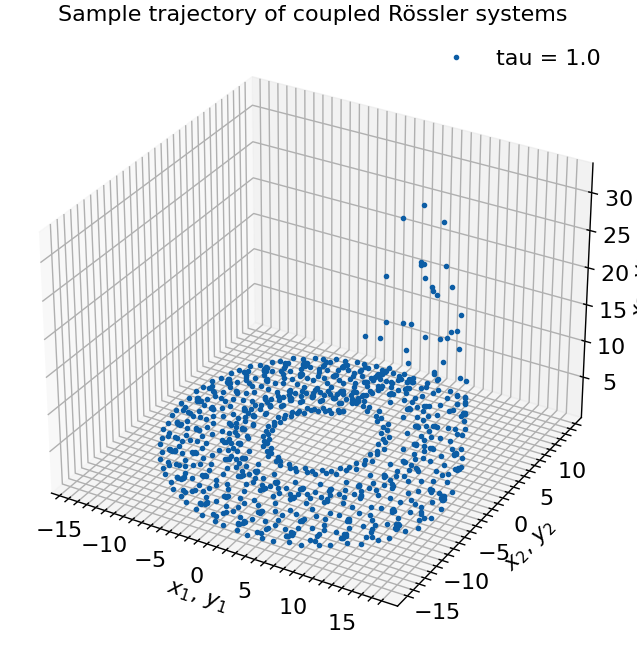

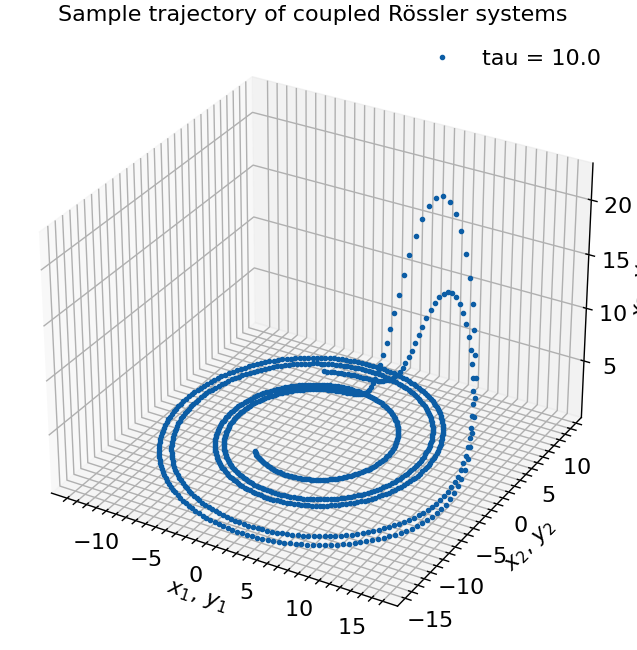

In [21]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs/seed0_itau{itau_eq}.p","rb"))

    #samples = np.linspace(5000, 200000, 1000, dtype=int)
    start_plot = 198000
    end_plot = 198900 #+ int(500 * taus_eq[itau_eq])

    x_1 = trajectory[start_plot:end_plot,1]
    x_2 = trajectory[start_plot:end_plot,2]
    x_3 = trajectory[start_plot:end_plot,3]
    #x_1 = trajectory[samples,1]
    #x_2 = trajectory[samples,2]
    #x_3 = trajectory[samples,3]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(x_1, x_2, x_3, '.', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$x_1,\,y_1$")
    ax.set_ylabel("$x_2,\,y_2$")
    ax.set_zlabel("$x_3,\,y_3$")
    plt.legend()
    plt.show()

### Plot attractors of Y for different tau_eq

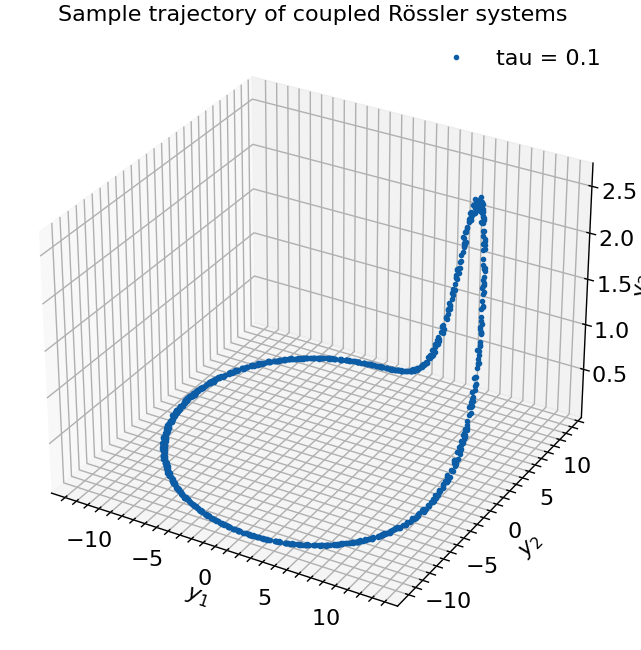

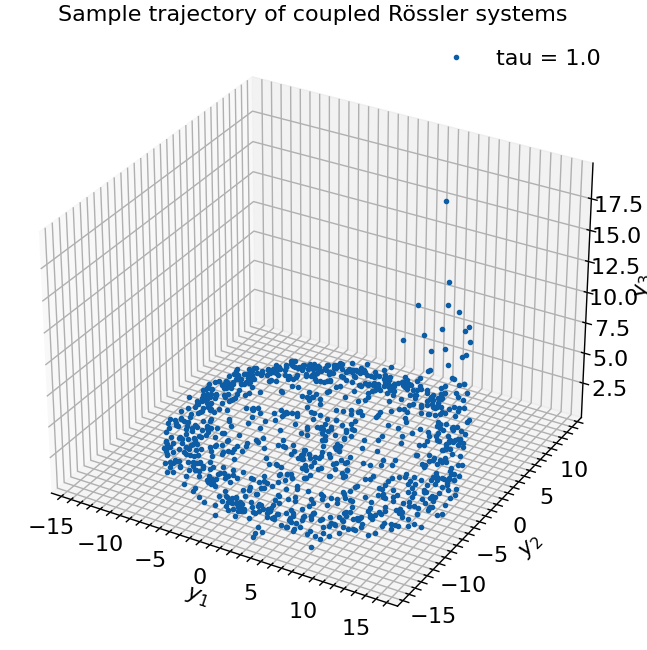

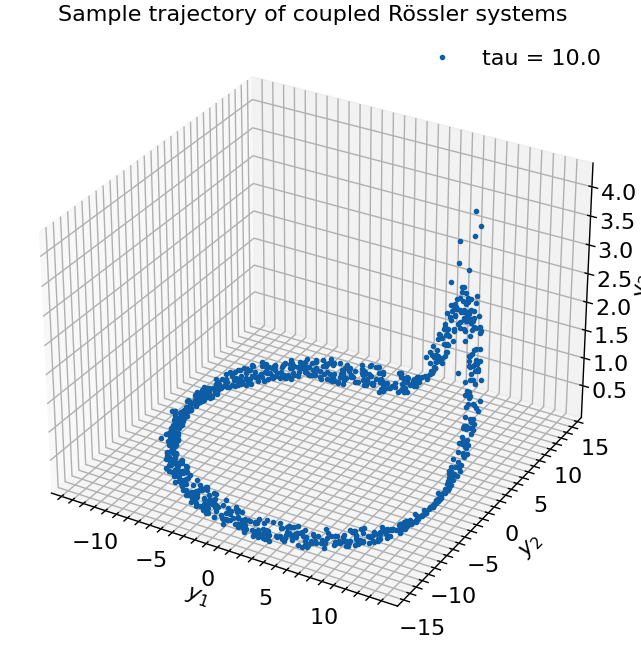

In [24]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs/seed0_itau{itau_eq}.p","rb"))

    samples = np.linspace(5000, 200000, 1000, dtype=int)
    #start_plot = 198000
    #end_plot = 199900 #+ int(500 * taus_eq[itau_eq])

    #y_1 = trajectory[start_plot:end_plot,4]
    #y_2 = trajectory[start_plot:end_plot,5]
    #y_3 = trajectory[start_plot:end_plot,6]

    y_1 = trajectory[samples,4]
    y_2 = trajectory[samples,5]
    y_3 = trajectory[samples,6]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(y_1, y_2, y_3, '.', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$y_1$")
    ax.set_ylabel("$y_2$")
    ax.set_zlabel("$y_3$")
    plt.legend()
    plt.show()

### Delta(X(0) -> X(tau/tau_eq)) and Delta(Y(0) -> Y(tau/tau_eq)) vs tau_eq

In [31]:
taus_eq = np.logspace(-1,1,21)
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_X = np.zeros((nseeds,len(taus_eq)))
info_imbalances_Y_to_Y = np.zeros((nseeds,len(taus_eq))) 
for seed in range(nseeds):
    info_imbalances_X_to_X[seed], info_imbalances_Y_to_Y[seed] = pickle.load(open(f"./imbalance_allcoords/pickles/seed{seed}.p","rb"))

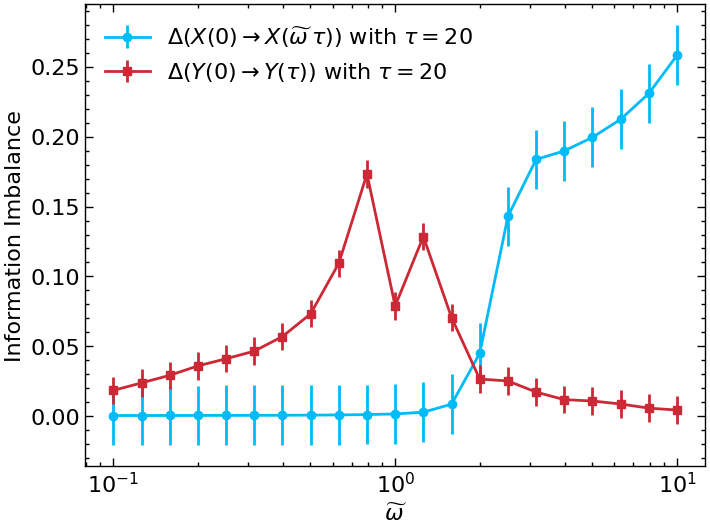

In [43]:
plt.errorbar(1/taus_eq, info_imbalances_X_to_X.mean(axis=0), info_imbalances_X_to_X.mean(axis=0).std(axis=0)/np.sqrt(20), fmt='o-', 
    color=colors[0], label="$\\Delta(X(0)\\rightarrow X(\\widetilde{\\omega}\,\\tau))$ with $\\tau = 20$")
plt.errorbar(1/taus_eq, info_imbalances_Y_to_Y.mean(axis=0), info_imbalances_Y_to_Y.mean(axis=0).std(axis=0)/np.sqrt(20), fmt='s-', 
    color=colors[1], label="$\\Delta(Y(0)\\rightarrow Y(\\tau))$ with $\\tau = 20$")
plt.legend()
plt.xlabel("$\\widetilde{\\omega}$")
plt.ylabel("Information Imbalance")
plt.xscale("log")
#plt.yscale("log")
plt.show()

### Compare attractors of (tau=1, unders=4) and (tau=5, unders=20)

(205001, 7)
(205001, 7)


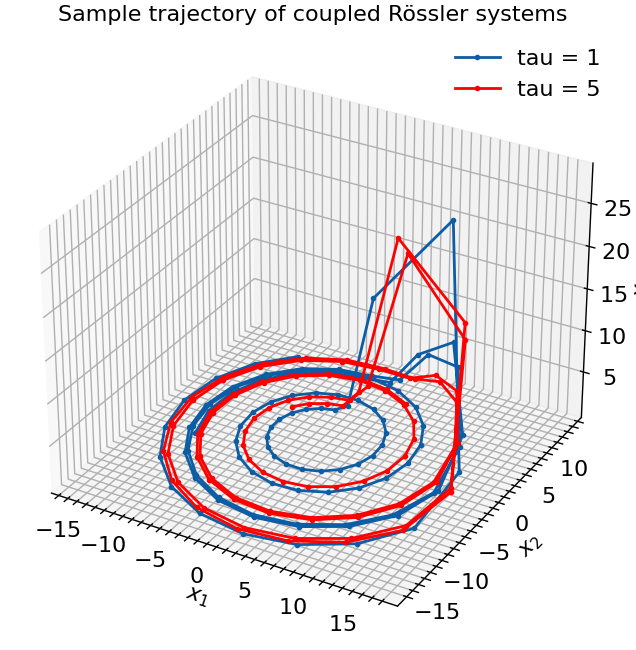

In [39]:
# X system
plt.rcParams['font.size'] = 16

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

#samples = np.linspace(5000, 200000, 1000, dtype=int)
start_plot = 200000#0
end_plot = 200100#30

trajectory = pickle.load(open(f"./trajs_identical/seed0_itau10.p","rb"))
print(trajectory.shape)
x_1 = trajectory[start_plot:end_plot,1]
x_2 = trajectory[start_plot:end_plot,2]
x_3 = trajectory[start_plot:end_plot,3]
ax.plot3D(x_1, x_2, x_3, '.-', label=f"tau = 1")

trajectory = pickle.load(open(f"./trajs_smallertau_largerundersample/seed0_tau5_unders20.p","rb"))
print(trajectory.shape)
x_1 = trajectory[start_plot:end_plot,1]
x_2 = trajectory[start_plot:end_plot,2]
x_3 = trajectory[start_plot:end_plot,3]
ax.plot3D(x_1, x_2, x_3, '.-', color="red", label=f"tau = 5")

ax.set_title("Sample trajectory of coupled Rössler systems")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
plt.legend()
plt.show()

(205001, 7)
(205001, 7)


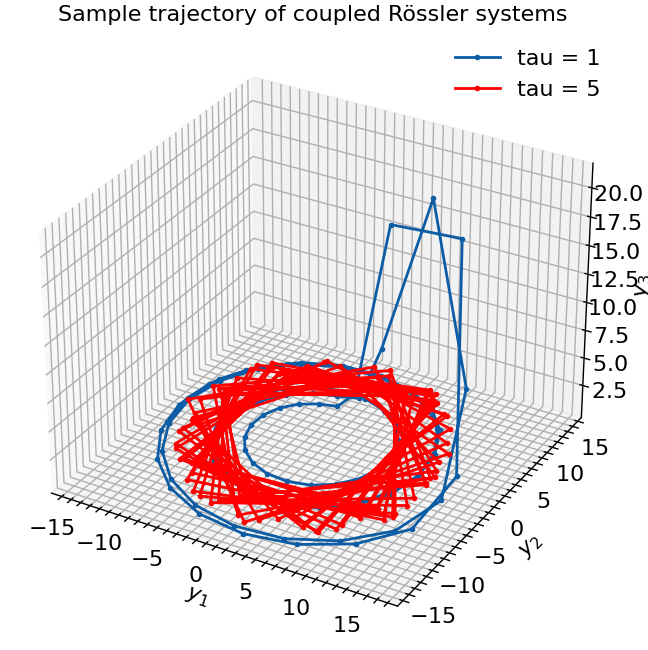

In [40]:
# Y system
plt.rcParams['font.size'] = 16

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

samples = np.linspace(5000, 200000, 1000, dtype=int)
start_plot = 200000#0
end_plot = 200100#30


trajectory = pickle.load(open(f"./trajs_identical/seed0_itau10.p","rb"))
print(trajectory.shape)
y_1 = trajectory[start_plot:end_plot,4]
y_2 = trajectory[start_plot:end_plot,5]
y_3 = trajectory[start_plot:end_plot,6]
ax.plot3D(y_1, y_2, y_3, '.-', label=f"tau = 1")

trajectory = pickle.load(open(f"./trajs_smallertau_largerundersample/seed0_tau5_unders20.p","rb"))
print(trajectory.shape)
y_1 = trajectory[start_plot:end_plot,4]
y_2 = trajectory[start_plot:end_plot,5]
y_3 = trajectory[start_plot:end_plot,6]
ax.plot3D(y_1, y_2, y_3, '.-', color="red", label=f"tau = 5")

ax.set_title("Sample trajectory of coupled Rössler systems")
ax.set_xlabel("$y_1$")
ax.set_ylabel("$y_2$")
ax.set_zlabel("$y_3$")
plt.legend()
plt.show()

### Lorenz 96

In [4]:
taus_eq = np.logspace(-1,1,21)
Ls = np.linspace(100,30000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(taus_eq),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(taus_eq),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(taus_eq)))
egc_index_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/lorenz96/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(taus_eq),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(taus_eq),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/lorenz96/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(taus_eq)))
L_Y_to_X = np.zeros((nseeds,len(taus_eq)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/lorenz96/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(taus_eq)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(taus_eq))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"./transfer_entropy/pickles/lorenz96/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])


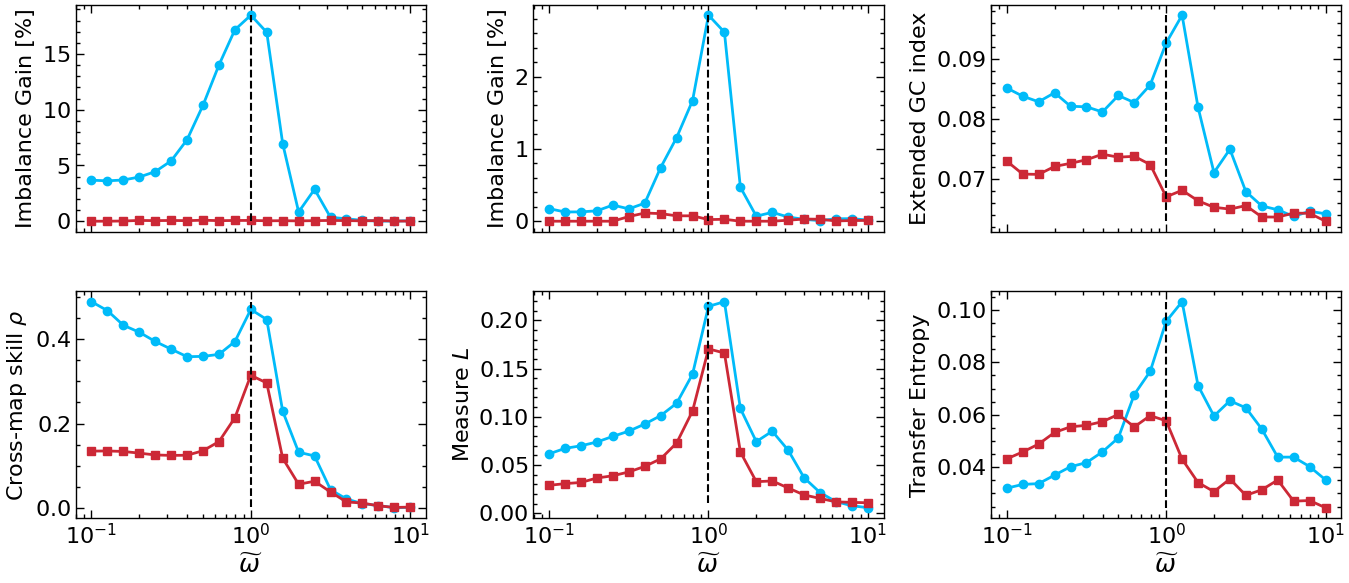

In [26]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()
min = 0.3
max = 3.1

indices = np.arange(0,21)#np.sort(np.append(np.arange(0,21,3), [10,20]))

#ax[0,0].errorbar(1/taus_eq[indices], IGs_X_to_Y[indices], IGs_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,0].errorbar(1/taus_eq[indices], IGs_Y_to_X[indices], IGs_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(1/taus_eq[indices], IGs_X_to_Y[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,0].plot(1/taus_eq[indices], IGs_Y_to_X[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,0].vlines(1., np.min(IGs_Y_to_X[indices]), np.max(IGs_X_to_Y[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,0].set(ylabel="Imbalance Gain [%]", xscale="log")#, xlim=[min,max])
ax[0,0].axes.xaxis.set_ticklabels([])

#ax[0,1].errorbar(1/taus_eq[indices], IGs_X_to_Y_emb[indices], IGs_X_to_Y_err_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,1].errorbar(1/taus_eq[indices], IGs_Y_to_X_emb[indices], IGs_Y_to_X_err_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(1/taus_eq[indices], IGs_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,1].plot(1/taus_eq[indices], IGs_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,1].vlines(1., np.min(IGs_Y_to_X_emb[indices]), np.max(IGs_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,1].set(ylabel="Imbalance Gain [%]", xscale="log")#,, xlim=[min,max])
ax[0,1].axes.xaxis.set_ticklabels([])

#ax[0,2].errorbar(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], egc_index_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[0,2].errorbar(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], egc_index_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[0,2].plot(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[0,2].vlines(1., np.min(egc_index_Y_to_X_avg[indices]), np.max(egc_index_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,2].set(ylabel="Extended GC index", xscale="log")#,, xlim=[min,max])
ax[0,2].axes.xaxis.set_ticklabels([])

#ax[1,0].errorbar(1/taus_eq[indices], ccm_X_to_Y_avg[indices], ccm_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,0].errorbar(1/taus_eq[indices], ccm_Y_to_X_avg[indices], ccm_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(1/taus_eq[indices], ccm_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,0].plot(1/taus_eq[indices], ccm_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,0].vlines(1., np.min(ccm_Y_to_X_avg[indices]), np.max(ccm_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,0].set(ylabel="Cross-map skill $\\rho$", xscale="log")#,, xlim=[min,max])
ax[1,0].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,1].errorbar(1/taus_eq[indices], L_X_to_Y_avg[indices], L_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,1].errorbar(1/taus_eq[indices], L_Y_to_X_avg[indices], L_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(1/taus_eq[indices], L_X_to_Y_avg[indices], 'o-', color=colors[0])#, alpha=0.4)#
ax[1,1].plot(1/taus_eq[indices], L_Y_to_X_avg[indices], 's-', color=colors[1])#, alpha=0.4)#
ax[1,1].vlines(1., np.min(L_Y_to_X_avg[indices]), np.max(L_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,1].set(ylabel="Measure $L$", xscale="log")#,, xlim=[min,max])
ax[1,1].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], TE_err_X_to_Y_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
#ax[1,2].errorbar(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], TE_err_Y_to_X_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].plot(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], 'o-', color=colors[0])#, alpha=0.4)
ax[1,2].plot(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], 's-', color=colors[1])#, alpha=0.4)
ax[1,2].vlines(1., np.min(TE_mean_Y_to_X_emb[indices]), np.max(TE_mean_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,2].set(ylabel="Transfer Entropy", xscale="log")#,, xlim=[min,max])
ax[1,2].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

#plt.savefig("./figures/measures_vs_omega_L96.pdf", dpi=300, bbox_inches='tight')
plt.show()

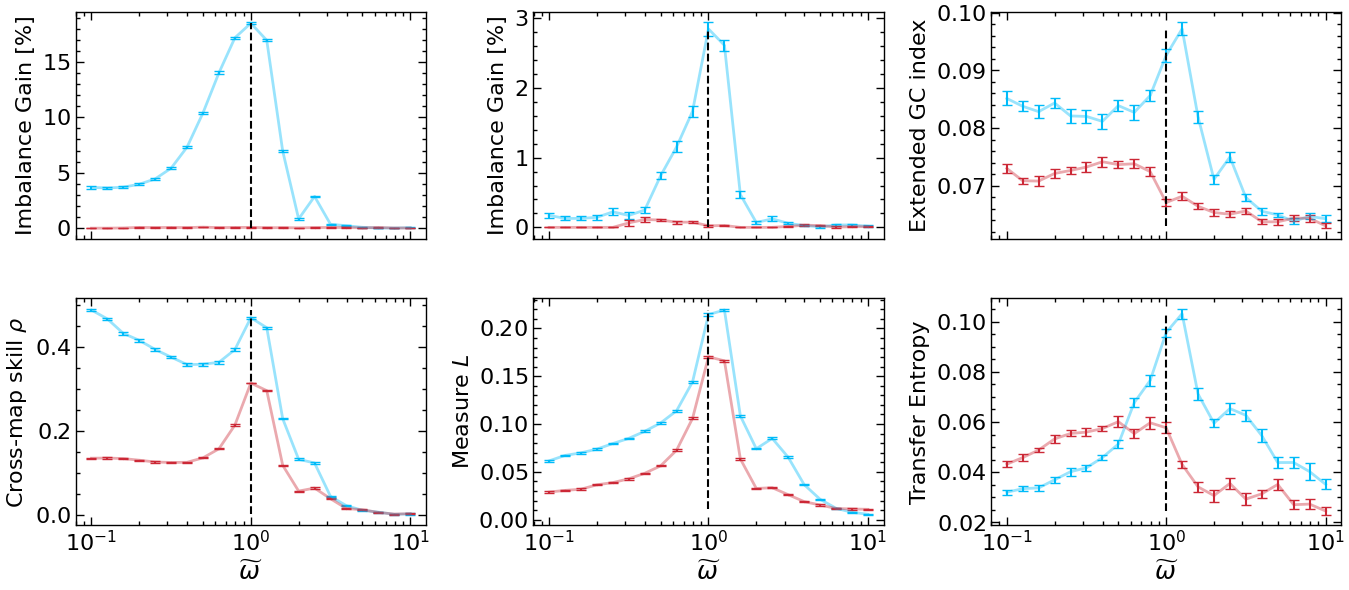

In [5]:
# FINAL PLOT!
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()
min = 0.3
max = 3.1

indices = np.arange(0,21)#np.sort(np.append(np.arange(0,21,3), [10,20]))

ax[0,0].errorbar(1/taus_eq[indices], IGs_X_to_Y[indices], IGs_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].errorbar(1/taus_eq[indices], IGs_Y_to_X[indices], IGs_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(1/taus_eq[indices], IGs_X_to_Y[indices], '-', color=colors[0], alpha=0.4)
ax[0,0].plot(1/taus_eq[indices], IGs_Y_to_X[indices], '-', color=colors[1], alpha=0.4)
ax[0,0].vlines(1., np.min(IGs_Y_to_X[indices]), np.max(IGs_X_to_Y[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,0].set(ylabel="Imbalance Gain [%]", xscale="log")#, xlim=[min,max])
ax[0,0].axes.xaxis.set_ticklabels([])

ax[0,1].errorbar(1/taus_eq[indices], IGs_X_to_Y_emb[indices], IGs_X_to_Y_err_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].errorbar(1/taus_eq[indices], IGs_Y_to_X_emb[indices], IGs_Y_to_X_err_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(1/taus_eq[indices], IGs_X_to_Y_emb[indices], '-', color=colors[0], alpha=0.4)
ax[0,1].plot(1/taus_eq[indices], IGs_Y_to_X_emb[indices], '-', color=colors[1], alpha=0.4)
ax[0,1].vlines(1., np.min(IGs_Y_to_X_emb[indices]), np.max(IGs_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,1].set(ylabel="Imbalance Gain [%]", xscale="log")#,, xlim=[min,max])
ax[0,1].axes.xaxis.set_ticklabels([])

ax[0,2].errorbar(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], egc_index_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].errorbar(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], egc_index_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(1/taus_eq[indices], egc_index_X_to_Y_avg[indices], '-', color=colors[0], alpha=0.4)
ax[0,2].plot(1/taus_eq[indices], egc_index_Y_to_X_avg[indices], '-', color=colors[1], alpha=0.4)
ax[0,2].vlines(1., np.min(egc_index_Y_to_X_avg[indices]), np.max(egc_index_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[0,2].set(ylabel="Extended GC index", xscale="log")#,, xlim=[min,max])
ax[0,2].axes.xaxis.set_ticklabels([])

ax[1,0].errorbar(1/taus_eq[indices], ccm_X_to_Y_avg[indices], ccm_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].errorbar(1/taus_eq[indices], ccm_Y_to_X_avg[indices], ccm_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(1/taus_eq[indices], ccm_X_to_Y_avg[indices], '-', color=colors[0], alpha=0.4)
ax[1,0].plot(1/taus_eq[indices], ccm_Y_to_X_avg[indices], '-', color=colors[1], alpha=0.4)
ax[1,0].vlines(1., np.min(ccm_Y_to_X_avg[indices]), np.max(ccm_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,0].set(ylabel="Cross-map skill $\\rho$", xscale="log")#,, xlim=[min,max])
ax[1,0].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

ax[1,1].errorbar(1/taus_eq[indices], L_X_to_Y_avg[indices], L_X_to_Y_err[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].errorbar(1/taus_eq[indices], L_Y_to_X_avg[indices], L_Y_to_X_err[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(1/taus_eq[indices], L_X_to_Y_avg[indices], '-', color=colors[0], alpha=0.4)#
ax[1,1].plot(1/taus_eq[indices], L_Y_to_X_avg[indices], '-', color=colors[1], alpha=0.4)#
ax[1,1].vlines(1., np.min(L_Y_to_X_avg[indices]), np.max(L_X_to_Y_avg[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,1].set(ylabel="Measure $L$", xscale="log")#,, xlim=[min,max])
ax[1,1].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

ax[1,2].errorbar(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], TE_err_X_to_Y_emb[indices], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].errorbar(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], TE_err_Y_to_X_emb[indices], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,2].plot(1/taus_eq[indices], TE_mean_X_to_Y_emb[indices], '-', color=colors[0], alpha=0.4)
ax[1,2].plot(1/taus_eq[indices], TE_mean_Y_to_X_emb[indices], '-', color=colors[1], alpha=0.4)
ax[1,2].vlines(1., np.min(TE_mean_Y_to_X_emb[indices]), np.max(TE_mean_X_to_Y_emb[indices]), linestyle='--', color="black", linewidth=1.5)
ax[1,2].set(ylabel="Transfer Entropy", xscale="log")#,, xlim=[min,max])
ax[1,2].set_xlabel("$\\widetilde{\\omega}$", fontsize=18)

plt.savefig("./figures/measures_vs_omega_L96_errors.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# false positive detections in direction Y -> X
fpd_imb_Y_to_X = (compute_t_stat(IGs_Y_to_X, IGs_Y_to_X_err) > t_19).sum()
fpd_imb_emb_Y_to_X = (compute_t_stat(IGs_Y_to_X_emb, IGs_Y_to_X_err_emb) > t_19).sum()
fpd_egc_Y_to_X = (compute_t_stat(egc_index_Y_to_X_avg, egc_index_Y_to_X_err) > t_19).sum()
fpd_ccm_Y_to_X = (compute_t_stat(ccm_Y_to_X_avg, ccm_Y_to_X_err) > t_19).sum()
fpd_L_Y_to_X = (compute_t_stat(L_Y_to_X_avg, L_Y_to_X_err) > t_19).sum()
fpd_te_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_imb_Y_to_X}\t{100*fpd_imb_Y_to_X/len(taus_eq):.2f}")
print(f"IGemb:\t{fpd_imb_emb_Y_to_X}\t{100*fpd_imb_emb_Y_to_X/len(taus_eq):.2f}")
print(f"egc:\t{fpd_egc_Y_to_X}\t{100*fpd_egc_Y_to_X/len(taus_eq):.2f}")
print(f"ccm:\t{fpd_ccm_Y_to_X}\t{100*fpd_ccm_Y_to_X/len(taus_eq):.2f}")
print(f"L:\t{fpd_L_Y_to_X}\t{100*fpd_L_Y_to_X/len(taus_eq):.2f}")
print(f"TE:\t{fpd_te_Y_to_X}\t{100*fpd_te_Y_to_X/len(taus_eq):.2f}\n")
print(f"Number of espilons considered: {len(taus_eq)}")

Number and % of false positive detections:
IG:	2	9.52
IGemb:	3	14.29
egc:	21	100.00
ccm:	19	90.48
L:	21	100.00
TE:	21	100.00

Number of espilons considered: 21


### Plot attractors of X for different tau_eq

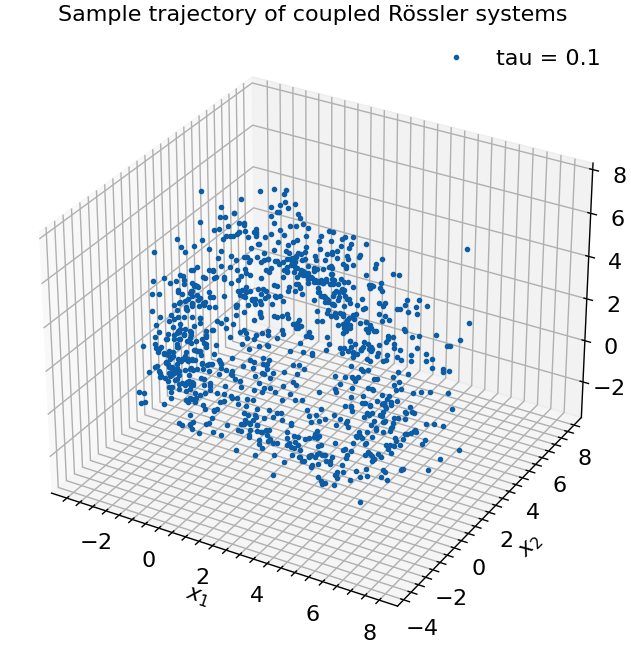

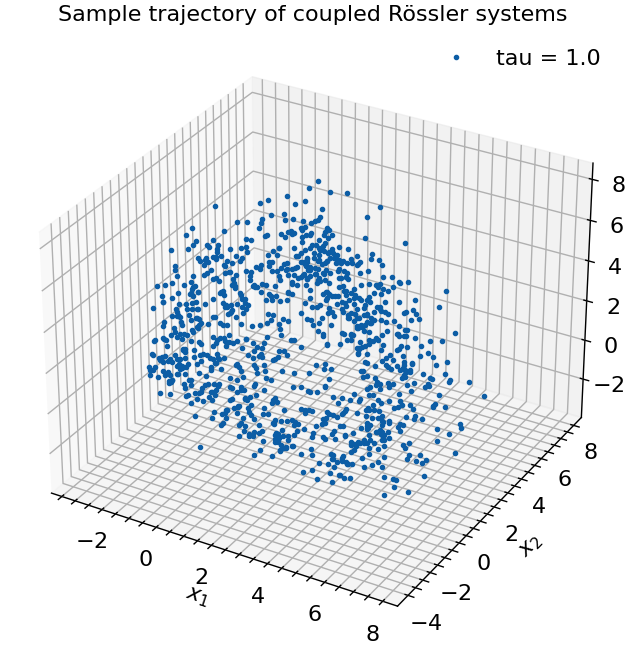

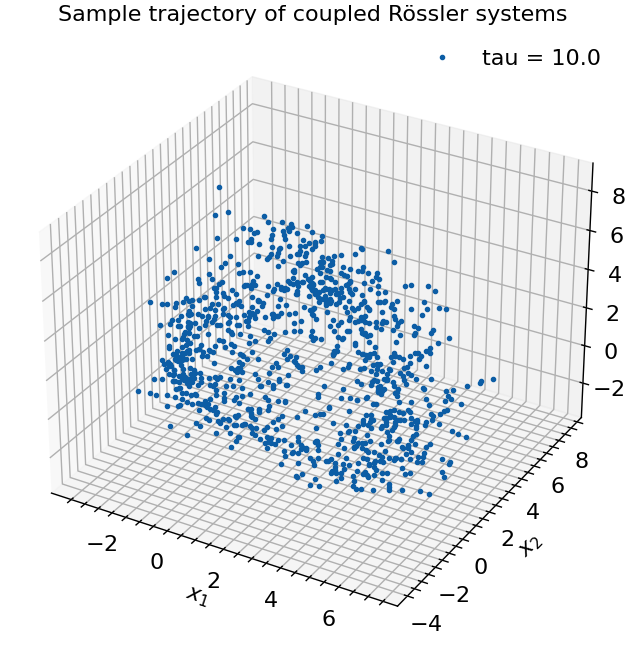

In [13]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs/lorenz96/seed0_itau{itau_eq}.p","rb"))

    samples = np.linspace(5000, 200000, 1000, dtype=int)
    #start_plot = 198000
    #end_plot = 198900 #+ int(500 * taus_eq[itau_eq])

    #x_1 = trajectory[start_plot:end_plot,1]
    #x_2 = trajectory[start_plot:end_plot,2]
    #x_3 = trajectory[start_plot:end_plot,3]
    x_1 = trajectory[samples,1]
    x_2 = trajectory[samples,2]
    x_3 = trajectory[samples,3]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(x_1, x_2, x_3, '.', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("$x_3$")
    plt.legend()
    plt.show()

### Plot attractors of Y for different tau_eq

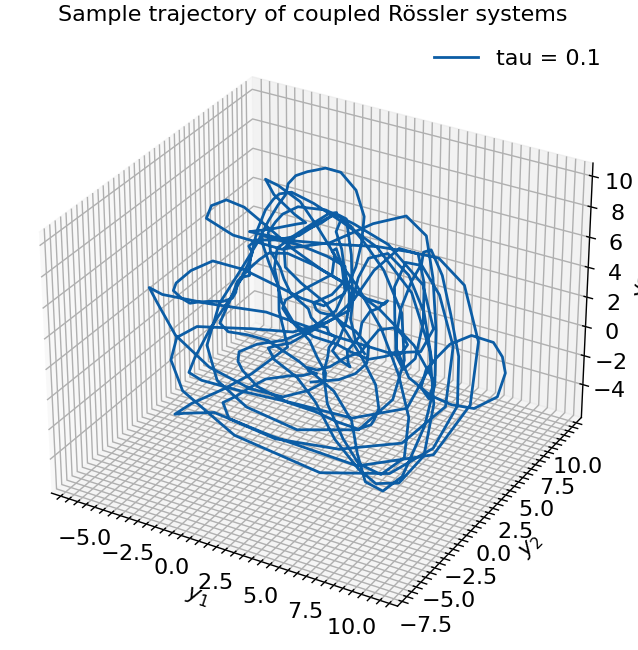

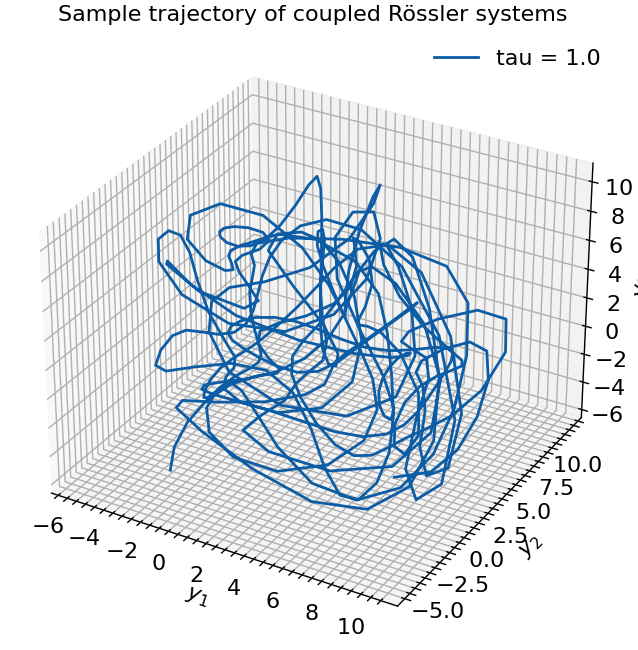

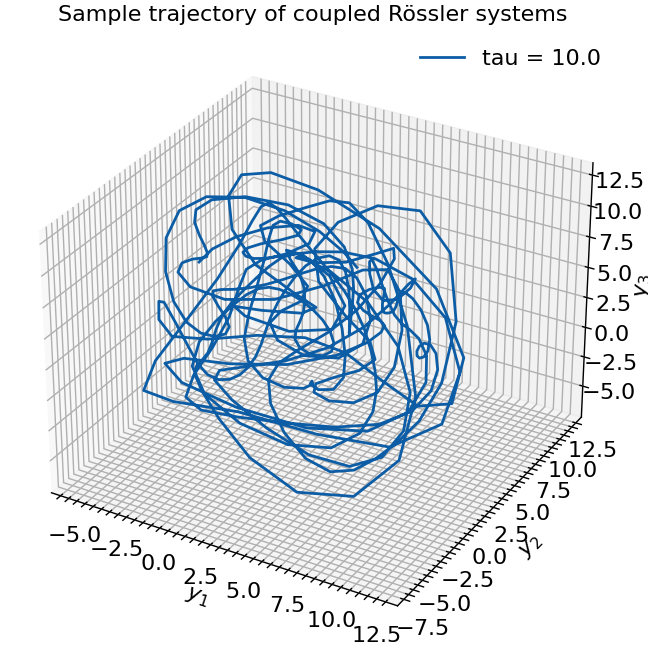

In [20]:
plt.rcParams['font.size'] = 16

for itau_eq in [0,10,20]:
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    trajectory = pickle.load(open(f"./trajs/lorenz96/seed0_itau{itau_eq}.p","rb"))

    #samples = np.linspace(5000, 200000, 1000, dtype=int)
    start_plot = 199500
    end_plot = 199900 #+ int(500 * taus_eq[itau_eq])

    y_1 = trajectory[start_plot:end_plot,41]
    y_2 = trajectory[start_plot:end_plot,42]
    y_3 = trajectory[start_plot:end_plot,43]

    #y_1 = trajectory[samples,45]
    #y_2 = trajectory[samples,46]
    #y_3 = trajectory[samples,47]

    #if itau_eq in [5, 10, 15]:
    ax.plot3D(y_1, y_2, y_3, '-', label=f"tau = {taus_eq[itau_eq]}")

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$y_1$")
    ax.set_ylabel("$y_2$")
    ax.set_zlabel("$y_3$")
    plt.legend()
    plt.show()